In [2]:

import pandas as pd



In [3]:
df = pd.read_csv('C:\\Users\\Hima\\Downloads\\news\\news.csv')


In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [5]:
# getting features, i explicitly specified text and title previously, but if i were to do the same her then it would be a baby project.
# what im doing now is creating an 'auto-detect' feature that would pick the features on its own when a new dataset is given.
# otherwise, whats the point of building a model that would work only on one dataset :/


possible_text_cols = ['text', 'title', 'content', 'headline', 'body', 'news', 'article']
possible_label_cols = ['label', 'labels', 'target', 'class', 'truth', 'is_fake']

text_col = None
label_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break
for col in possible_label_cols:
    if col in df.columns:
        label_col = col
        break
if text_col is None or label_col is None:
    print("Could not auto-detect text/label column. Edit 'text_col' and 'label_col' manually.")
    print('Available Columns: ', df.columns.tolist())
    raise SystemExit

print(f'Using text column: {text_col} - label column: {label_col}')

#checking what labels i got:
print('\nLabel Distribution:')
print(df[label_col].value_counts())

# simplifying strings like 'real' or 'fake' to binary to make calulations, since it only understands numbers :)

if df[label_col].dtype == 'object':
    df[label_col] = df[label_col].str.lower().map(lambda x: 1 if 'real' in x or 'true' in x or 'genuine' in x else 0 )




Using text column: text - label column: label

Label Distribution:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


In [6]:
## Preprocessing (clean data), simply removing the punctuations, extra spaces and non-words.
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')


lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

url_re = re.compile(r'https?://\S+|www\.\S+')

def preprocess_text(s: str): 
    s = str(s).lower()
    s = url_re.sub(' ', s) # substitute urls with a space, that will be removed anyway since it would create multiple spaces
    tokens = nltk.word_tokenize(s)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]    
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)






[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hima\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [7]:
print('\npreprocess test:', preprocess_text('xyz is shot down. to read nonsense, visit: www.blablah.com or https://www.lajkl.com'))


#works like a charm ;)


preprocess test: xyz shot read nonsense visit


In [8]:
# applying preprocesing (more data = more time, simple enough)
sample = False
if sample:
    df = df.sample(n=5000, random_state=42).reset_index(drop=True)

print('n\preprocessing text column...')
df['clean_text']= df[text_col].astype(str).map(preprocess_text)
print('Done. Example to cool you down:')
print(df['clean_text'].head())



n\preprocessing text column...


<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Hima\AppData\Local\Temp\ipykernel_10076\2011175633.py:6: SyntaxWarning: invalid escape sequence '\p'
  print('n\preprocessing text column...')


Done. Example to cool you down:
0    daniel greenfield shillman journalism fellow f...
1    google pinterest digg linkedin reddit stumbleu...
2    u.s. secretary state john f. kerry said monday...
3    kaydee king kaydeeking november 2016 lesson to...
4    's primary day new york front-runner hillary c...
Name: clean_text, dtype: object


In [9]:
# tf-idf and train-test split finally omfg

X  = df['clean_text'].values
y = df[label_col].values

#train test split
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, y_train,y_test = train_test_split(X,y, test_size=.2, random_state=42, stratify=y)

print('Train Size:', len(X_train_text), "Test Size:", len(X_test_text))

#vectorizatio, it just means converting text to numbers, simple enough.
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.fit_transform(X_test_text)

print('TF-IDF shape - train:', X_train.shape, 'test:', X_test.shape)



Train Size: 5068 Test Size: 1267
TF-IDF shape - train: (5068, 2000) test: (1267, 2000)


In [10]:
# Now comes the cool part, model training and comparison, god i was so fucking bored of those infinite lecture sessions.
# there are 3 models, but i only recognise 2 of them, multinomialNB is new to me. idfc, more the merrier :)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
models = {

    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial NB': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=200,n_jobs=-1,random_state=42)
}

results = {}
for name, model in models.items():
    print('\nTraining ', name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(name, 'accuracy: ', round(acc,4))
    print(classification_report(y_test, y_pred))
    results[name] = {'model':model, 'accuracy': acc, 'y_pred': y_pred}





Training  Logistic Regression
Logistic Regression accuracy:  0.6306
              precision    recall  f1-score   support

           0       0.59      0.88      0.70       633
           1       0.76      0.38      0.51       634

    accuracy                           0.63      1267
   macro avg       0.67      0.63      0.61      1267
weighted avg       0.67      0.63      0.61      1267


Training  Multinomial NB
Multinomial NB accuracy:  0.6338
              precision    recall  f1-score   support

           0       0.64      0.63      0.63       633
           1       0.63      0.64      0.64       634

    accuracy                           0.63      1267
   macro avg       0.63      0.63      0.63      1267
weighted avg       0.63      0.63      0.63      1267


Training  Random Forest
Random Forest accuracy:  0.7064
              precision    recall  f1-score   support

           0       0.70      0.71      0.71       633
           1       0.71      0.70      0.70       63

In [11]:
## initially i went for 20000 vocab for tf-idf, but it gave me horrible accuracy and recall on all models, mostly between 40-50 accuracy, and the recall was greatly unbalanced.
## then tweaked it all the way 10000, it got slightly better, but nott astronomical difference.
## the most optimal number of features for this specific dataset that i found was 2000.
## rf got a 70.64% accuracy, and the recall rate was also very balanced (0 = .71, 1 = .70).


Best model:  Random Forest accuracy:  0.7063930544593529


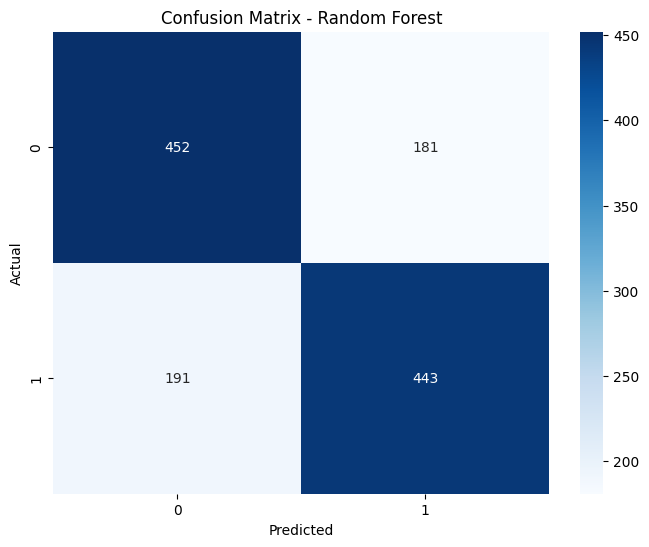

In [12]:
#confusion matrix for the best model. this is the best chart for this kind of stuff where results are in 0s and 1s

import matplotlib.pyplot as plt
import seaborn as sns

best_name =  max(results.keys(), key=lambda k: results[k]['accuracy'])
best_model  = results[best_name]['model']
print('\nBest model: ',best_name, 'accuracy: ', results[best_name]['accuracy'])

cm = confusion_matrix(y_test, results[best_name]['y_pred'])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

In [13]:
## Saving the best model + vectorizer

import joblib

model_path = 'best_news_model.joblib'
vect_path = 'tfidf_vectorizer.joblib'
joblib.dump(best_model, model_path)
joblib.dump(vectorizer, vect_path)
print('Saved: ', model_path, vect_path)



Saved:  best_news_model.joblib tfidf_vectorizer.joblib


In [28]:
## Finally, a small interactive demo - predict on single sample (yayy)

def predict_text(model, vect, text):
    clean = preprocess_text(text)
    X = vect.transform([clean])
    pred = model.predict(X)[0]
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X).max()
    return pred, prob

# example

sample = ''
pred, prob = predict_text(best_model, vectorizer, sample)
print('\nSample:', sample)
print('Predicted label (1=real,0=fake): ',  pred, )


Sample: 
Predicted label (1=real,0=fake):  0
